# Linear vs MLP Probe Comparison

Select one protein-level or residue-level probing dataset, one embedding model, and one layer. The notebook generates that layer in memory, trains matched linear and MLP probes, and compares their held-out metrics across one or more random seeds.


## Goal

Use this as a focused follow-up to the layer-sweep notebook when the layer is already chosen and the question is whether a linear readout is enough or whether a small MLP improves performance.


In [1]:
from __future__ import annotations

from dataclasses import replace
import gc
import math
import os
from pathlib import Path
import sys
from typing import Sequence

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "CBBIO").exists() else NOTEBOOK_DIR.parent
if not (REPO_ROOT / "CBBIO").exists():
    raise RuntimeError("Could not find the CBBIO package directory. Start Jupyter from the repo root or notebooks/.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

# Reset previous in-memory embeddings when re-running the notebook in an existing kernel.
globals().pop("embeddings", None)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.ipc_collect()

from CBBIO import (
    GenerationInput,
    Generator,
    PredictionSpec,
    ProbeSpec,
    ProteinDataset,
    ResidueDataset,
    Task,
    collect_generation_results,
    compute_residue_feature_stats,
    compute_residue_flat_data,
    filter_redundant_to_test_mmseqs,
    get_dataset_catalog_entry,
    list_dataset_catalog,
    load_dataset,
    load_peer_dataset,
    run_task_on_layer,
)
from CBBIO.embeddings import EmbeddingDependencyError, EmbeddingInputError

pd.set_option("display.max_colwidth", 120)


## Setup

Edit the configuration values directly, or use the optional widget panel in the next section. For protein-level datasets, embeddings are mean-pooled by default. For residue-level datasets, unpooled per-residue embeddings are used.


In [ ]:
DATA_ROOT = Path("data/probing")

# Select either a protein-level or residue-level dataset from the unified catalog.
DATASET_ID = "ec:ec_3_subclass_holdout_head"
DOWNLOAD_DATA = True
PEER_SPLIT: str | Sequence[str] | None = None

# Keep these bounded while iterating. Set to None for full splits.
MAX_TRAIN_EXAMPLES: int | None = 100000
MAX_VAL_EXAMPLES: int | None = 10000
MAX_TEST_EXAMPLES: int | None = 10000
MAX_SEQUENCE_LENGTH: int | None = 1024
FILTER_REDUNDANT_TO_TEST = True
REDUNDANCY_IDENTITY_CUTOFF = 30.0
REDUNDANCY_MIN_COVERAGE = 0.8

# Embedding generation controls. This notebook intentionally uses one layer only.
MODEL_CLASS = "esmc"
MODEL_NAME = "esmc_600m"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SELECTED_LAYER = -1
POOLER: str | None = "auto"  # auto -> mean for protein tasks, none for residue tasks
EMBEDDING_BATCH_SIZE = 8
MAX_BATCH_TOKENS: int | None = 32768
LENGTH_SORT_WINDOW: int | None = 256

# Matched probe configuration. Keep epochs/lr/batch aligned unless intentionally testing optimization differences.
LINEAR_PROBE = ProbeSpec(kind="linear", epochs=50, learning_rate=0.001, batch_size=8192, seed=7)
MLP_PROBE = ProbeSpec(kind="mlp", epochs=50, learning_rate=0.001, batch_size=8192, hidden_dim=512, seed=7)
PROBE_SEEDS: Sequence[int] = (7, 11, 23)
METRIC = "f1"  # None chooses a task-appropriate metric automatically.

# Runtime resource controls.
MAX_CPU_THREADS: int | None = min(4, os.cpu_count() or 1)
MAX_TORCH_INTEROP_THREADS: int | None = 4
DISABLE_TOKENIZERS_PARALLELISM = False


## Apply Runtime Resource Limits

In [3]:
def apply_runtime_resource_limits(*, max_cpu_threads: int | None, max_torch_interop_threads: int | None, disable_tokenizers_parallelism: bool) -> None:
    thread_env = {
        "OMP_NUM_THREADS": max_cpu_threads,
        "MKL_NUM_THREADS": max_cpu_threads,
        "OPENBLAS_NUM_THREADS": max_cpu_threads,
        "NUMEXPR_NUM_THREADS": max_cpu_threads,
    }
    for name, value in thread_env.items():
        if value is None:
            os.environ.pop(name, None)
        else:
            os.environ[name] = str(int(value))

    if disable_tokenizers_parallelism:
        os.environ["TOKENIZERS_PARALLELISM"] = "false"
    else:
        os.environ.pop("TOKENIZERS_PARALLELISM", None)

    if max_cpu_threads is not None:
        torch.set_num_threads(int(max_cpu_threads))
    if max_torch_interop_threads is not None:
        try:
            torch.set_num_interop_threads(int(max_torch_interop_threads))
        except RuntimeError as exc:
            print(f"Could not update torch interop threads without a kernel restart: {exc}")

    print(
        "Applied resource limits:",
        {
            "max_cpu_threads": max_cpu_threads,
            "max_torch_interop_threads": max_torch_interop_threads,
            "tokenizers_parallelism": "false" if disable_tokenizers_parallelism else "auto",
        },
    )


apply_runtime_resource_limits(
    max_cpu_threads=MAX_CPU_THREADS,
    max_torch_interop_threads=MAX_TORCH_INTEROP_THREADS,
    disable_tokenizers_parallelism=DISABLE_TOKENIZERS_PARALLELISM,
)


Applied resource limits: {'max_cpu_threads': 4, 'max_torch_interop_threads': 4, 'tokenizers_parallelism': 'auto'}


## Steps

### 1. Search And Resolve The Dataset

In [4]:

dataset_entry = get_dataset_catalog_entry(DATASET_ID)

if dataset_entry.status not in {"ready", "adapter"}:
    raise EmbeddingInputError(f"Dataset {dataset_entry.id!r} is not loadable yet: status={dataset_entry.status!r}.")

RESOLVED_POOLER = ("mean" if dataset_entry.level == "protein" else None) if POOLER == "auto" else POOLER
pd.DataFrame([dataset_entry.__dict__]).T.rename(columns={0: "value"})


,value
id,ec:single_ec_3_head
name,single_ec_3_head
display_name,Single-label EC level 3 (head)
collection,ec
source,UniRef50 EC annotations
category,function_prediction
task_class,function
preferred_metric,accuracy
description,Source: UniRef50 EC annotations. Class: function_prediction. Split system: fixed train/validation/test splits strati...
level,protein


### 2. Load The Dataset

In [5]:
def _peer_split_limits() -> dict[str, int | None]:
    return {
        "train": MAX_TRAIN_EXAMPLES,
        "valid": MAX_VAL_EXAMPLES,
        "val": MAX_VAL_EXAMPLES,
        "validation": MAX_VAL_EXAMPLES,
        "test": MAX_TEST_EXAMPLES,
        "cb513": MAX_TEST_EXAMPLES,
        "casp12": MAX_TEST_EXAMPLES,
        "ts115": MAX_TEST_EXAMPLES,
        "test_fold_holdout": MAX_TEST_EXAMPLES,
        "test_family_holdout": MAX_TEST_EXAMPLES,
        "test_superfamily_holdout": MAX_TEST_EXAMPLES,
    }


def load_selected_dataset(entry) -> ProteinDataset | ResidueDataset:
    if entry.collection == "peer":
        try:
            dataset = load_peer_dataset(
                DATA_ROOT,
                name=entry.name,
                split=PEER_SPLIT,
                download=True,
                max_examples_per_split=_peer_split_limits(),
            )
        except EmbeddingDependencyError as exc:
            if "lmdb" in str(exc).lower():
                raise EmbeddingDependencyError(
                    "PEER native datasets require the optional 'lmdb' package. Install notebook extras with "
                    "`poetry install --extras notebooks`, or run `poetry add lmdb`. Restart the kernel after installing."
                ) from exc
            raise
        except EmbeddingInputError as exc:
            if "Missing PEER LMDB files" in str(exc):
                raise EmbeddingInputError(
                    "Dataset files are missing. Set DOWNLOAD_DATA = True, or enable 'Download data' in the widget panel "
                    "and click 'Apply widget values', then rerun this cell."
                ) from exc
            raise
        if entry.level == "protein" and not isinstance(dataset, ProteinDataset):
            raise EmbeddingInputError(f"Expected ProteinDataset, got {type(dataset).__name__}.")
        if entry.level == "residue" and not isinstance(dataset, ResidueDataset):
            raise EmbeddingInputError(f"Expected ResidueDataset, got {type(dataset).__name__}.")
        return dataset
    return load_dataset(
        entry.id,
        DATA_ROOT,
        target=entry.target,
        download=DOWNLOAD_DATA,
    )


def limit_split_examples(
    dataset: ProteinDataset | ResidueDataset,
    *,
    max_train: int | None,
    max_val: int | None,
    max_test: int | None,
) -> ProteinDataset | ResidueDataset:
    train_seen = 0
    val_seen = 0
    test_seen = 0
    selected = []
    for example in dataset.examples:
        if example.split == "train":
            if max_train is not None and train_seen >= max_train:
                continue
            train_seen += 1
            selected.append(example)
        elif example.split == "val":
            if max_val is not None and val_seen >= max_val:
                continue
            val_seen += 1
            selected.append(example)
        elif example.split == "test":
            if max_test is not None and test_seen >= max_test:
                continue
            test_seen += 1
            selected.append(example)
    return ResidueDataset(selected) if isinstance(dataset, ResidueDataset) else ProteinDataset(selected)


def filter_sequence_length(dataset: ProteinDataset | ResidueDataset, *, max_length: int | None) -> ProteinDataset | ResidueDataset:
    if max_length is None:
        return dataset
    selected = [example for example in dataset.examples if len(example.sequence) <= max_length]
    skipped = len(dataset.examples) - len(selected)
    if skipped:
        print(f"Skipped {skipped} examples longer than MAX_SEQUENCE_LENGTH={max_length} before building the task.")
    if not selected:
        raise EmbeddingInputError("Sequence-length filtering removed every example. Increase MAX_SEQUENCE_LENGTH.")
    return ResidueDataset(selected) if isinstance(dataset, ResidueDataset) else ProteinDataset(selected)


def ensure_train_test_splits(
    dataset: ProteinDataset | ResidueDataset,
    *,
    train_fraction: float = 0.8,
) -> ProteinDataset | ResidueDataset:
    counts = dataset.split_counts()
    if counts["train"] > 0 and counts["test"] > 0:
        return dataset

    ordered = sorted(dataset.examples, key=lambda example: example.id)
    total = len(ordered)
    if total < 2:
        raise EmbeddingInputError("Need at least two examples to construct train/test splits for probing after filtering.")

    n_train = int(round(total * train_fraction))
    n_train = max(1, min(total - 1, n_train))
    reassigned = [
        replace(example, split=("train" if index < n_train else "test"))
        for index, example in enumerate(ordered)
    ]
    rebuilt = ResidueDataset(reassigned) if isinstance(dataset, ResidueDataset) else ProteinDataset(reassigned)
    rebuilt_counts = rebuilt.split_counts()
    print(
        "Dataset had missing train/test split after loading/filtering; "
        f"assigned deterministic splits by id: train={rebuilt_counts['train']}, test={rebuilt_counts['test']}."
    )
    return rebuilt


def filter_redundant_train_val_to_test(dataset: ProteinDataset | ResidueDataset) -> ProteinDataset | ResidueDataset:
    if not FILTER_REDUNDANT_TO_TEST:
        return dataset
    filtered, report = filter_redundant_to_test_mmseqs(
        dataset,
        cutoff=REDUNDANCY_IDENTITY_CUTOFF,
        min_coverage=REDUNDANCY_MIN_COVERAGE,
        threads=MAX_CPU_THREADS,
    )
    print(
        "MMseqs train/val-to-test redundancy filter: "
        f"removed={report.removed_count}, retained={report.retained_count}, "
        f"reference_test={report.reference_count}, cutoff={report.cutoff:.1f}%, "
        f"min_coverage={report.min_coverage:.2f}."
    )
    return filtered


dataset = load_selected_dataset(dataset_entry)
dataset = limit_split_examples(
    dataset,
    max_train=MAX_TRAIN_EXAMPLES,
    max_val=MAX_VAL_EXAMPLES,
    max_test=MAX_TEST_EXAMPLES,
)
dataset = filter_sequence_length(dataset, max_length=MAX_SEQUENCE_LENGTH)
dataset = filter_redundant_train_val_to_test(dataset)
dataset = ensure_train_test_splits(dataset)
dataset.split_counts()


Skipped 2028 examples longer than MAX_SEQUENCE_LENGTH=1024 before building the task.
MMseqs train/val-to-test redundancy filter: removed=12379, retained=19772, reference_test=2964, cutoff=30.0%, min_coverage=0.80.


{'train': 15669, 'val': 1139, 'test': 2964}

### 3. Build The Task

In [6]:
base_task = Task(
    name=dataset_entry.id,
    dataset=dataset,
    prediction=PredictionSpec(
        target=dataset_entry.target,
        objective=dataset_entry.objective,
        level=dataset_entry.level,
    ),
    probe=LINEAR_PROBE,
)

base_task


Task(name='ec:single_ec_3_head', dataset=<CBBIO.probing.datasets.ProteinDataset object at 0x79cddd8f1cd0>, prediction=PredictionSpec(target='single_ec_3', objective='multiclass', level='protein', classes=None, metrics=None), probe=ProbeSpec(kind='linear', epochs=50, learning_rate=0.001, batch_size=8192, weight_decay=0.0, hidden_dim=64, seed=7))

### 4. Generate Embeddings For One Layer

In [7]:
generator = Generator(model_class=MODEL_CLASS, name=MODEL_NAME, device=DEVICE)
try:
    available_layers = generator.available_layers()
except Exception:
    available_layers = []

if available_layers and SELECTED_LAYER not in available_layers:
    resolved_negative_layer = available_layers[SELECTED_LAYER] if SELECTED_LAYER < 0 and abs(SELECTED_LAYER) <= len(available_layers) else None
    if resolved_negative_layer is None:
        raise EmbeddingInputError(
            f"Layer {SELECTED_LAYER} is not available for {MODEL_CLASS}:{MODEL_NAME}. Available: {available_layers}"
        )

{
    "model_reference": generator.model_reference,
    "selected_layer": SELECTED_LAYER,
    "pooler": RESOLVED_POOLER,
    "available_layers_sample": available_layers[:10],
}


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

{'model_reference': 'biohub/ESMC-600M',
 'selected_layer': -1,
 'pooler': 'mean',
 'available_layers_sample': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]}

In [8]:
def generation_inputs_from_dataset(dataset: ProteinDataset | ResidueDataset) -> list[GenerationInput]:
    return [
        GenerationInput(id=example.id, sequence=example.sequence)
        for example in dataset.examples
        if example.split in {"train", "test"}
    ]


records = generation_inputs_from_dataset(dataset)
if not records:
    raise EmbeddingInputError("No train/test sequences are available for embedding generation.")

from CBBIO import collect_generation_results

result = collect_generation_results(
    tqdm(
        generator.generate_batches(
            records,
            batch_size=EMBEDDING_BATCH_SIZE,
            max_batch_tokens=MAX_BATCH_TOKENS,
            length_sort_window=LENGTH_SORT_WINDOW,
            layer_index=SELECTED_LAYER,
            pooler=RESOLVED_POOLER,
            fail_fast=True,
        ),
        total=math.ceil(len(records) / EMBEDDING_BATCH_SIZE),
        desc="Embedding batches",
    )
)

if result.errors:
    raise EmbeddingInputError(f"Embedding generation produced {len(result.errors)} errors. First error: {result.errors[0]}")
if not result.records:
    raise EmbeddingInputError("Embedding generation did not return any records.")

generated_layer_index = int(result.records[0].layer_index)
embeddings = {
    record.id: np.asarray(record.embedding, dtype=np.float32)
    for record in result.records
    if int(record.layer_index) == generated_layer_index
}

if len(embeddings) != len(records):
    missing_ids = sorted({record.id for record in records} - set(embeddings))
    raise EmbeddingInputError(f"Missing embeddings for {len(missing_ids)} records. First missing ids: {missing_ids[:5]}")

expected_rank = 2 if dataset_entry.level == "residue" else 1
bad_shapes = {key: value.shape for key, value in embeddings.items() if value.ndim != expected_rank}
if bad_shapes:
    raise EmbeddingInputError(f"Expected rank-{expected_rank} embeddings for {dataset_entry.level} task. Bad shapes: {bad_shapes}")

del generator
del result
gc.collect()

print(f"Loaded {len(embeddings)} embedding arrays from layer {generated_layer_index}.")


Embedding batches:   0%|          | 0/2330 [00:00<?, ?it/s]

Loaded 18633 embedding arrays from layer 35.


### 5. Train Linear And MLP Probes

In [9]:
probe_seeds = list(dict.fromkeys(int(seed) for seed in PROBE_SEEDS))
if not probe_seeds:
    raise EmbeddingInputError("Set PROBE_SEEDS to at least one seed.")

probe_templates = {
    "linear": LINEAR_PROBE,
    "mlp": MLP_PROBE,
}


def _probe_with_seed(template: ProbeSpec, seed: int) -> ProbeSpec:
    return ProbeSpec(
        kind=template.kind,
        epochs=template.epochs,
        learning_rate=template.learning_rate,
        batch_size=template.batch_size,
        weight_decay=template.weight_decay,
        hidden_dim=template.hidden_dim,
        seed=int(seed),
    )


def _prediction_count_key(value) -> object:
    if isinstance(value, list | tuple):
        return "+".join(str(item) for item in value) if value else "<none>"
    return value


def _classification_examples(dataset: ProteinDataset | ResidueDataset) -> tuple[list, list]:
    if isinstance(dataset, ResidueDataset):
        return [], []
    return dataset.require_training_and_test_splits()


def _class_names(train_labels: Sequence[object], test_labels: Sequence[object]) -> list[str]:
    return sorted({str(label) for label in [*train_labels, *test_labels]})


def _multiclass_metrics(true_labels: Sequence[object], predicted_labels: Sequence[object]) -> dict[str, float]:
    classes = _class_names(predicted_labels, true_labels)
    if len(classes) < 2:
        return {}
    correct = sum(str(true) == str(predicted) for true, predicted in zip(true_labels, predicted_labels))
    f1_values = []
    for label in classes:
        tp = sum(str(true) == label and str(predicted) == label for true, predicted in zip(true_labels, predicted_labels))
        fp = sum(str(true) != label and str(predicted) == label for true, predicted in zip(true_labels, predicted_labels))
        fn = sum(str(true) == label and str(predicted) != label for true, predicted in zip(true_labels, predicted_labels))
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1_values.append(2.0 * precision * recall / (precision + recall) if precision + recall else 0.0)
    return {
        "accuracy": correct / len(true_labels),
        "macro_f1": sum(f1_values) / len(f1_values),
    }


def _multilabel_indicator(labels: Sequence[str], *, classes: Sequence[str]) -> list[int]:
    selected = {str(label) for label in labels}
    return [1 if label in selected else 0 for label in classes]


def _multilabel_metrics(true_labels: Sequence[Sequence[str]], predicted_labels: Sequence[Sequence[str]]) -> dict[str, float]:
    classes = sorted({str(label) for labels in [*true_labels, *predicted_labels] for label in labels})
    if not classes:
        return {}
    true_matrix = [_multilabel_indicator(labels, classes=classes) for labels in true_labels]
    predicted_matrix = [_multilabel_indicator(labels, classes=classes) for labels in predicted_labels]
    exact_match = sum(true == predicted for true, predicted in zip(true_matrix, predicted_matrix)) / len(true_matrix)
    macro_f1_values = []
    micro_tp = micro_fp = micro_fn = 0
    for class_index in range(len(classes)):
        true_values = [row[class_index] for row in true_matrix]
        predicted_values = [row[class_index] for row in predicted_matrix]
        tp = sum(true == 1 and predicted == 1 for true, predicted in zip(true_values, predicted_values))
        fp = sum(true == 0 and predicted == 1 for true, predicted in zip(true_values, predicted_values))
        fn = sum(true == 1 and predicted == 0 for true, predicted in zip(true_values, predicted_values))
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        macro_f1_values.append(2.0 * precision * recall / (precision + recall) if precision + recall else 0.0)
        micro_tp += tp
        micro_fp += fp
        micro_fn += fn
    micro_precision = micro_tp / (micro_tp + micro_fp) if micro_tp + micro_fp else 0.0
    micro_recall = micro_tp / (micro_tp + micro_fn) if micro_tp + micro_fn else 0.0
    micro_f1 = 2.0 * micro_precision * micro_recall / (micro_precision + micro_recall) if micro_precision + micro_recall else 0.0
    return {
        "exact_match": exact_match,
        "micro_f1": micro_f1,
        "macro_f1": sum(macro_f1_values) / len(macro_f1_values),
    }


def _baseline_rows(task: Task, *, seeds: Sequence[int]) -> list[dict[str, object]]:
    train_examples, test_examples = _classification_examples(task.dataset)
    if not train_examples or task.prediction.objective not in {"binary", "multiclass", "multilabel"}:
        return []
    target = task.prediction.target
    train_labels = [example.labels[target] for example in train_examples]
    test_labels = [example.labels[target] for example in test_examples]
    rows = []

    if task.prediction.objective == "multilabel":
        train_label_sets = [tuple(str(label) for label in labels) for labels in train_labels]
        test_label_sets = [tuple(str(label) for label in labels) for labels in test_labels]
        majority_set = pd.Series([_prediction_count_key(labels) for labels in train_label_sets], dtype="object").value_counts().idxmax()
        majority_labels = tuple() if majority_set == "<none>" else tuple(str(majority_set).split("+"))
        baseline_specs = [("baseline_majority", [majority_labels for _ in test_label_sets], None)]
        for seed in seeds:
            rng = np.random.default_rng(seed)
            sampled_indices = rng.choice(len(train_label_sets), size=len(test_label_sets), replace=True)
            baseline_specs.append(("baseline_train_prior", [train_label_sets[index] for index in sampled_indices], seed))
        for name, predictions, seed in baseline_specs:
            rows.append({
                "dataset_id": dataset_entry.id,
                "dataset_level": dataset_entry.level,
                "model_class": MODEL_CLASS,
                "model_name": MODEL_NAME,
                "probe": name,
                "seed": seed,
                "layer": generated_layer_index,
                "elapsed_seconds": 0.0,
                "train_count": len(train_examples),
                "val_count": len(task.dataset.by_split("val")),
                "test_count": len(test_examples),
                **_multilabel_metrics(test_label_sets, predictions),
            })
        return rows

    train_scalar = [str(label) for label in train_labels]
    test_scalar = [str(label) for label in test_labels]
    majority_label = pd.Series(train_scalar, dtype="object").value_counts().idxmax()
    baseline_specs = [("baseline_majority", [majority_label for _ in test_scalar], None)]
    for seed in seeds:
        rng = np.random.default_rng(seed)
        baseline_specs.append(("baseline_train_prior", list(rng.choice(train_scalar, size=len(test_scalar), replace=True)), seed))
    for name, predictions, seed in baseline_specs:
        rows.append({
            "dataset_id": dataset_entry.id,
            "dataset_level": dataset_entry.level,
            "model_class": MODEL_CLASS,
            "model_name": MODEL_NAME,
            "probe": name,
            "seed": seed,
            "layer": generated_layer_index,
            "elapsed_seconds": 0.0,
            "train_count": len(train_examples),
            "val_count": len(task.dataset.by_split("val")),
            "test_count": len(test_examples),
            **_multiclass_metrics(test_scalar, predictions),
        })
    return rows


feature_mean, feature_std, flat_data = None, None, None
if base_task.prediction.level == "residue":
    train_examples, test_examples = base_task.dataset.require_training_and_test_splits()
    masks = {example.id: example.mask for example in base_task.dataset.examples}
    feature_mean, feature_std = compute_residue_feature_stats(
        train_ids=[example.id for example in train_examples],
        embeddings=embeddings,
        masks=masks,
    )
    flat_data = compute_residue_flat_data(
        train_ids=[example.id for example in train_examples],
        test_ids=[example.id for example in test_examples],
        embeddings=embeddings,
        masks=masks,
    )

per_run_rows = []
for probe_name, probe_template in probe_templates.items():
    for seed in tqdm(probe_seeds, desc=f"{probe_name} seeds", unit="seed"):
        seeded_task = Task(
            name=base_task.name,
            dataset=base_task.dataset,
            prediction=base_task.prediction,
            probe=_probe_with_seed(probe_template, seed),
        )
        probe_result = run_task_on_layer(
            task=seeded_task,
            embeddings=embeddings,
            model_reference=f"{MODEL_CLASS}:{MODEL_NAME}",
            layer_index=generated_layer_index,
            feature_mean=feature_mean,
            feature_std=feature_std,
            flat_data=flat_data,
        )
        prediction_counts = (
            pd.Series([_prediction_count_key(value) for value in probe_result.predictions.values()], dtype="object")
            .value_counts(dropna=False)
            .to_dict()
        )
        per_run_rows.append(
            {
                "dataset_id": dataset_entry.id,
                "dataset_level": dataset_entry.level,
                "model_class": MODEL_CLASS,
                "model_name": MODEL_NAME,
                "probe": probe_name,
                "seed": seed,
                "layer": generated_layer_index,
                "elapsed_seconds": probe_result.elapsed_seconds,
                "train_count": probe_result.train_count,
                "val_count": probe_result.val_count,
                "test_count": probe_result.test_count,
                **probe_result.metrics,
                **{f"pred_{label}_count": int(count) for label, count in prediction_counts.items()},
            }
        )

baseline_rows = _baseline_rows(base_task, seeds=probe_seeds)
if baseline_rows:
    per_run_rows.extend(baseline_rows)

per_run_results = pd.DataFrame(per_run_rows).sort_values(["probe", "seed"], na_position="first").reset_index(drop=True)
numeric_columns = [
    column
    for column in per_run_results.columns
    if column not in {"seed", "layer"} and pd.api.types.is_numeric_dtype(per_run_results[column])
]

results = per_run_results.groupby("probe", as_index=False)[numeric_columns].mean(numeric_only=True)
results_std = per_run_results.groupby("probe", as_index=False)[numeric_columns].std(numeric_only=True)
results_std = results_std.rename(columns={column: f"{column}_std" for column in numeric_columns})
results = results.merge(results_std, on="probe", how="left")
results.insert(1, "layer", generated_layer_index)

print(f"Aggregated probe scores across {len(probe_seeds)} seed(s): {probe_seeds}")
results


linear seeds:   0%|          | 0/3 [00:00<?, ?seed/s]

mlp seeds:   0%|          | 0/3 [00:00<?, ?seed/s]

Aggregated probe scores across 3 seed(s): [7, 11, 23]


,probe,layer,elapsed_seconds,train_count,val_count,test_count,accuracy,macro_f1,pred_2.7.11_count,pred_2.3.2_count,...,pred_4.3.3_count_std,pred_3.4.16_count_std,pred_2.2.1_count_std,pred_5.4.2_count_std,pred_2.1.3_count_std,pred_3.1.2_count_std,pred_6.2.1_count_std,pred_4.3.2_count_std,pred_1.3.1_count_std,pred_1.13.11_count_std
0,linear,35,3.127685,15669.0,1139.0,2964.0,0.629330,0.483902,621.666667,321.666667,...,0.0,0.0,0.000000,0.0,0.57735,NaN,0.0,NaN,NaN,NaN
1,mlp,35,2.418755,15669.0,1139.0,2964.0,0.644175,0.467922,595.000000,327.000000,...,NaN,1.0,1.154701,1.0,NaN,NaN,NaN,NaN,0.707107,NaN


## Checks

In [10]:
def choose_metric(results: pd.DataFrame, requested: str | None) -> str:
    if requested is not None:
        if requested not in results.columns:
            raise EmbeddingInputError(f"Requested metric {requested!r} is not present. Available: {list(results.columns)}")
        return requested
    preferred = ["macro_f1", "f1", "accuracy", "auroc", "spearmanr", "r2", "rmse", "mae"]
    for metric in preferred:
        if metric in results.columns:
            return metric
    metric_columns = [
        column
        for column in results.columns
        if column not in {"probe", "layer", "elapsed_seconds", "train_count", "val_count", "test_count"}
        and not column.endswith("_std")
    ]
    if not metric_columns:
        raise EmbeddingInputError("No metric columns found in probe results.")
    return metric_columns[0]


#metric = choose_metric(results, METRIC)
metric="macro_f1"
comparison_columns = ["probe", "layer", "elapsed_seconds", "train_count", "test_count", metric]
if f"{metric}_std" in results.columns:
    comparison_columns.append(f"{metric}_std")
comparison = results[[column for column in comparison_columns if column in results.columns]].copy()

metric_direction = "lower is better" if metric in {"rmse", "mae"} else "higher is better"
linear_value = float(results.loc[results["probe"] == "linear", metric].iloc[0])
mlp_value = float(results.loc[results["probe"] == "mlp", metric].iloc[0])
comparison["delta_vs_linear"] = comparison[metric] - linear_value
for baseline_name in ["baseline_majority", "baseline_train_prior"]:
    baseline_values = results.loc[results["probe"] == baseline_name, metric]
    if not baseline_values.empty:
        comparison[f"delta_vs_{baseline_name.removeprefix('baseline_')}"] = comparison[metric] - float(baseline_values.iloc[0])

print(f"Selected metric: {metric} ({metric_direction})")
print(f"MLP - linear delta: {mlp_value - linear_value:.6g}")
display(comparison)


paired_scores = per_run_results.pivot_table(index="seed", columns="probe", values=metric, aggfunc="mean")
paired_scores = paired_scores.dropna(subset=["linear", "mlp"])
if len(paired_scores) < 2:
    print("Paired t-test skipped: at least two seeds with both linear and mlp results are required.")
    t_test_result = pd.DataFrame()
else:
    paired_delta = paired_scores["mlp"] - paired_scores["linear"]
    mean_delta = float(paired_delta.mean())
    std_delta = float(paired_delta.std(ddof=1))
    t_statistic = math.inf if std_delta == 0 and mean_delta > 0 else (-math.inf if std_delta == 0 and mean_delta < 0 else (0.0 if std_delta == 0 else mean_delta / (std_delta / math.sqrt(len(paired_delta)))))
    p_value = None
    try:
        from scipy import stats

        scipy_result = stats.ttest_rel(paired_scores["mlp"], paired_scores["linear"], nan_policy="omit")
        t_statistic = float(scipy_result.statistic)
        p_value = float(scipy_result.pvalue)
    except Exception as exc:
        print(f"SciPy t-test unavailable; reporting t-statistic only. ({exc})")

    t_test_result = pd.DataFrame(
        [
            {
                "test": "paired_t_test",
                "metric": metric,
                "n_seed_pairs": int(len(paired_delta)),
                "mean_mlp_minus_linear": mean_delta,
                "std_mlp_minus_linear": std_delta,
                "t_statistic": t_statistic,
                "p_value": p_value,
            }
        ]
    )

display(t_test_result)

t_test_result


Selected metric: macro_f1 (higher is better)
MLP - linear delta: -0.0159801


,probe,layer,elapsed_seconds,train_count,test_count,macro_f1,macro_f1_std,delta_vs_linear
0,linear,35,3.127685,15669.0,2964.0,0.483902,0.011302,0.00000
1,mlp,35,2.418755,15669.0,2964.0,0.467922,0.007137,-0.01598


,test,metric,n_seed_pairs,mean_mlp_minus_linear,std_mlp_minus_linear,t_statistic,p_value
0,paired_t_test,macro_f1,3,-0.01598,0.012985,-2.131613,0.166714


,test,metric,n_seed_pairs,mean_mlp_minus_linear,std_mlp_minus_linear,t_statistic,p_value
0,paired_t_test,macro_f1,3,-0.01598,0.012985,-2.131613,0.166714


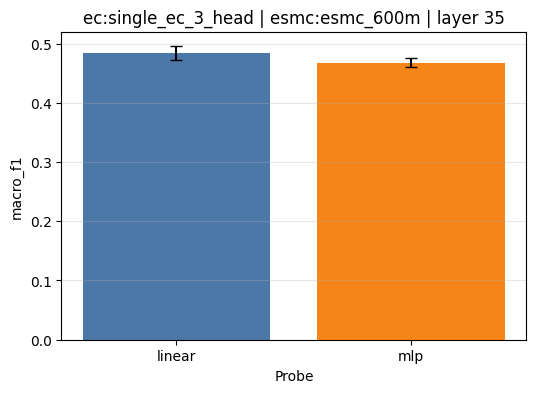

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
metric_std = f"{metric}_std"
yerr = results[metric_std].fillna(0.0) if metric_std in results.columns else None
ax.bar(results["probe"], results[metric], yerr=yerr, capsize=4, color=["#4C78A8", "#F58518"])
ax.set_xlabel("Probe")
ax.set_ylabel(metric)
ax.set_title(f"{dataset_entry.id} | {MODEL_CLASS}:{MODEL_NAME} | layer {generated_layer_index}")
ax.grid(axis="y", alpha=0.3)
plt.show()


## Next Steps

If the MLP only improves marginally, prefer the linear probe because it is easier to interpret as linearly accessible information. If the MLP improves materially, rerun this comparison on nearby layers and at least one additional dataset before treating the gain as model- or task-level evidence.
